# Search-12a — Composer des regards : play forward, coplay backward

[← Retour à la série](../README.md) · Précédent : [Search-11d — Descente sous budget](Search-11d-Descente-Sous-Budget.ipynb)

Grain de l'opération 12 « Composer des regards » du chantier 1 ICT ([See #12204](https://github.com/jsboige/CoursIA/issues/12204)). L'opération : un même problème se laisse lire **depuis le départ** (on *joue* la route en avant : que s'est-il accumulé ?) et **depuis l'arrivée** (on *co-joue* en arrière : que reste-t-il à payer ?). Composer les deux lectures donne une information qu'aucune des deux ne porte seule — à condition que les lectures soient **compatibles**. La première attestation ([GT-21, #12245](https://github.com/jsboige/CoursIA/pull/12245)) l'établit sur l'espace des jeux 2×2 (transformation vs morphisme) ; ce notebook l'instantiate sur un **substrat indépendant** — la recherche de chemin pondérée — où tout est mesurable au noeud près : coût, pas, ordre d'expansion.

Trois questions : (1) que transporte la composition de deux lectures **compatibles** ? (2) la composition est-elle **associative**, et quand le composé est-il **exact** ? (3) à quoi reconnaît-on une **paire de lectures incompatibles** — et que produit-elle de concret ?

## 1. Le terrain : un gridworld pondéré, déterministe

Grille 10×14 fixée en constantes (aucun tirage aléatoire) : plaine (coût 1), forêt (3), marais (8). Un **corridor bon marché serpentin** — long en pas — contourne un **marais posé sur la diagonale directe** — court en pas, cher en coût. Cette asymétrie est le germe de tout ce qui suit : deux lectures de la même grille (en coût, en pas) peuvent ne pas être d'accord. Oracle de vérité : Dijkstra exact, dans les deux sens.

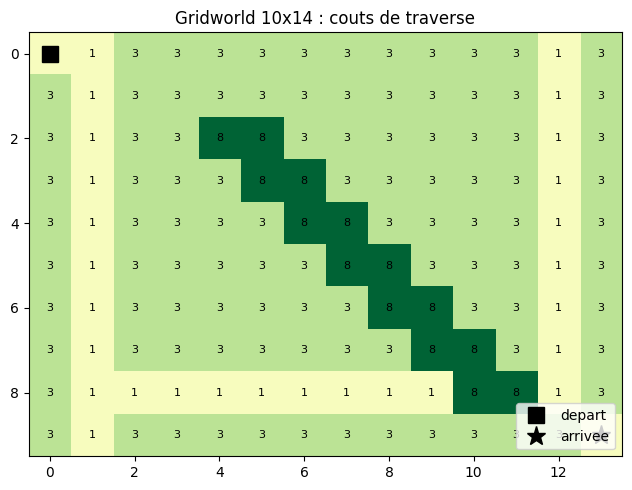

grille 10x14 fixee en constantes — deterministe, aucun tirage


In [1]:
import heapq
from collections import deque
import matplotlib.pyplot as plt
import numpy as np

W, H = 14, 10
PLAIN, FOREST, SWAMP = 1, 3, 8
COST = [[FOREST] * W for _ in range(H)]
for r in range(H):                       # corridor serpentin en plaine
    COST[r][1] = PLAIN
for c in range(1, W - 1):
    COST[H - 2][c] = PLAIN
for r in range(H - 2, -1, -1):
    COST[r][W - 2] = PLAIN
for i in range(2, min(W, H) - 1):        # marais sur la diagonale directe
    COST[i][i + 2] = SWAMP
    if i + 3 < W:
        COST[i][i + 3] = SWAMP
COST[0][0], COST[H - 1][W - 1] = PLAIN, PLAIN
START, GOAL = (0, 0), (H - 1, W - 1)

fig, ax = plt.subplots(figsize=(7.2, 5.0))
ax.imshow(np.array(COST), cmap="YlGn", vmin=0, vmax=9)
for r in range(H):
    for c in range(W):
        ax.text(c, r, COST[r][c], ha="center", va="center", fontsize=8)
ax.plot(START[1], START[0], "ks", markersize=12, label="depart")
ax.plot(GOAL[1], GOAL[0], "k*", markersize=14, label="arrivee")
ax.set_title("Gridworld 10x14 : couts de traverse")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

def neighbors(p):
    r, c = p
    for dr, dc in ((1, 0), (-1, 0), (0, 1), (0, -1)):
        nr, nc = r + dr, c + dc
        if 0 <= nr < H and 0 <= nc < W:
            yield (nr, nc)

def dijkstra(source, parents=None):
    dist = {source: 0}
    pq = [(0, source)]
    while pq:
        d, u = heapq.heappop(pq)
        if d > dist.get(u, 1 << 30):
            continue
        for v in neighbors(u):
            nd = d + COST[v[0]][v[1]]
            if nd < dist.get(v, 1 << 30):
                dist[v] = nd
                heapq.heappush(pq, (nd, v))
                if parents is not None:
                    parents[v] = u
    return dist

def bfs_steps(source):
    dist = {source: 0}
    q = deque([source])
    while q:
        u = q.popleft()
        for v in neighbors(u):
            if v not in dist:
                dist[v] = dist[u] + 1
                q.append(v)
    return dist

print(f"grille {H}x{W} fixee en constantes — deterministe, aucun tirage")

## 2. Les deux lectures, puis leur composition

**Play forward** : `g(n)` = coût exact accumulé du départ à `n` (Dijkstra depuis `START`) — la lecture de celui qui joue la route. **Coplay backward** : `d(n)` = coût exact restant de `n` à l'arrivée (Dijkstra depuis `GOAL`, coûts symétriques) — la lecture de celui qui remonte la partie depuis la fin. Le **composé** : `f*(n) = g(n) + d(n)`, le coût de la meilleure route *qui passe par* `n`.

In [2]:
g_fwd = dijkstra(START)     # play forward : ce qui s'est accumule
d_bwd = dijkstra(GOAL)     # coplay backward : ce qu'il reste a payer
OPT = g_fwd[GOAL]
f_star = {n: g_fwd[n] + d_bwd[n] for n in g_fwd}

print(f"meilleur cout total OPT = {OPT}")
print(f"g et d couvrent {len(g_fwd)} noeuds chacun (grille connexe 4-voisines)")

meilleur cout total OPT = 30
g et d couvrent 140 noeuds chacun (grille connexe 4-voisines)


## 3. Ce que transporte une composition compatible

Les deux lectures sont dans la **même métrique** (le coût). Loi attendue : `f*(n) >= OPT` pour tout `n`, **égalité exactement sur le corridor optimal** — le composé *focalise* : un best-first guidé par `f*` ne retient que le corridor, là où le Dijkstra uni-directionnel visite toute la grille.

In [3]:
corridor = sorted(n for n in g_fwd if f_star[n] == OPT)
loi_ok = all(f_star[n] >= OPT for n in g_fwd)
print(f"loi f* >= OPT partout : {loi_ok}")
print(f"corridor f* == OPT : {len(corridor)} noeuds sur {len(g_fwd)} ({100 * len(corridor) / len(g_fwd):.0f}% de la grille)")
print(f"Dijkstra uni-directionnel sort {len(g_fwd)} noeuds ; le compose n'en retient que {len(corridor)}")

loi f* >= OPT partout : True
corridor f* == OPT : 19 noeuds sur 140 (14% de la grille)
Dijkstra uni-directionnel sort 140 noeuds ; le compose n'en retient que 19


### Lecture

La loi tient (`f* >= OPT` partout) et l'égalité sélectionne exactement le corridor : **19 noeuds sur 140 (14 % de la grille)**. C'est le contenu informationnel de la composition : ni `g` seule (qui ne sait rien de l'arrivée) ni `d` seule (qui ne sait rien du départ) ne peut isoler ces 19 noeuds — leur somme le fait, parce qu'un noeud est sur une route optimale **ssi les deux lectures le confirment ensemble**. Le Dijkstra uni-directionnel, lui, doit sortir les 140 noeuds pour garantir son optimum : la composition achève la focalisation que chaque lecture ne faisait qu'ébaucher.

## 4. Associativité de la composition, exactitude du composé

Composer plus de deux lectures : une route à **relais** se lit `n -> m1 -> m2 -> arrivée` — un tronçon joué en avant (`n -> m1`), deux tronçons co-joués en arrière. L'**associativité** demande `((n->m1) + (m1->m2)) + (m2->G) == (n->m1) + ((m1->m2) + (m2->G))` : le regroupement des parenthèses ne change pas l'estimé. L'**exactitude** est plus fine : l'estimé chaîné n'égale la distance directe `n -> G` **que si les relais sont sur une route optimale** — sinon il surestime strictement (inégalité triangulaire). Associativité : une loi d'opérateur, toujours vraie. Exactitude : une condition de **cohérence entre les lectures**, mesurable.

In [4]:
parents = {START: START}
_ = dijkstra(START, parents)            # parents -> chemin optimal
chem = [GOAL]
while chem[-1] != START:
    chem.append(parents[chem[-1]])
chem = chem[::-1]
print(f"chemin optimal : {len(chem) - 1} pas, cout {sum(COST[r][c] for r, c in chem[1:])}")

m1, m2 = chem[len(chem) // 3], chem[2 * len(chem) // 3]   # relais SUR la route
n_on = chem[len(chem) // 6]
n_off = (3, 4)                                            # noeud hors route

def leg(a, b):
    return dijkstra(a)[b]

for nom, n in (("sur la route optimale", n_on), ("hors route", n_off)):
    a1, a2, a3 = leg(n, m1), leg(m1, m2), leg(m2, GOAL)
    lhs, rhs = (a1 + a2) + a3, a1 + (a2 + a3)
    direct = leg(n, GOAL)
    print(f"n {nom} {n} : assoc. {lhs == rhs} | chaines {lhs:>3} | direct {direct:>3} | exact {lhs == direct} | ecart {lhs - direct}")

chemin optimal : 22 pas, cout 30
n sur la route optimale (2, 1) : assoc. True | chaines  27 | direct  27 | exact True | ecart 0
n hors route (3, 4) : assoc. True | chaines  33 | direct  31 | exact False | ecart 2


### Lecture

Deux lois distinctes, mesurées. **Associativité : vraie dans les deux groupements** (`assoc. True` sur les deux lignes) — propriété de l'opérateur (addition de tronçons), indépendante du terrain. **Exactitude : conditionnelle.** Pour `n = (2, 1)`, relais et noeud sur la route optimale : chaîné 27 == direct 27, écart 0. Pour `n = (3, 4)`, hors route : chaîné 33 contre direct 31 — **surestimation stricte de +2**, l'inégalité triangulaire qui mord. Composer des lectures cohérentes ne sous-estime jamais ; mais l'estimé chaîné ne dit la vérité **que** quand les relais sont posés là où les lectures se croisent — sur une route optimale.

## 5. La paire incompatible, exhibée

Remplaçons la lecture arrière en coût par une lecture arrière **en pas** : `h_pas(n)` = distance BFS non pondérée vers l'arrivée. Chaque lecture est cohérente seule — mais la paire (avant-coût, arrière-pas) **mélange deux unités**. Loi attendue : le composé `g + h_pas` ne transporte plus la garantie. Témoin exigé par la table de l'opération : **la paire de lectures incompatibles exhibée** — ici, un glouton guidé par chaque lecture arrière, et le premier pas où les deux guides divergent.

In [5]:
steps_bwd = bfs_steps(GOAL)     # coplay backward en PAS (metrique etrangere au cout)

def greedy(h):
    cur, path = START, [START]
    while cur != GOAL:
        cur = min(neighbors(cur), key=lambda v: h.get(v, 1 << 30))
        path.append(cur)
    return path

def route_cost(path):
    return sum(COST[r][c] for r, c in path[1:])

pc, ps = greedy(d_bwd), greedy(steps_bwd)
div = next(i for i, (a, b) in enumerate(zip(pc, ps)) if a != b)
print(f"glouton guide par la lecture COUT : {len(pc) - 1} pas, cout {route_cost(pc)} (== OPT : {route_cost(pc) == OPT})")
print(f"glouton guide par la lecture PAS  : {len(ps) - 1} pas, cout {route_cost(ps)} (gap +{route_cost(ps) - OPT})")
print(f"premier pas de divergence : pas {div} — la lecture cout va en {pc[div]}, la lecture pas va en {ps[div]}")

def astar(h):
    closed, open_, ext = set(), [(h.get(START, 0), 0, START)], 0
    while open_:
        f, g, u = heapq.heappop(open_)
        if u in closed:
            continue
        ext += 1
        if u == GOAL:
            return g, ext
        closed.add(u)
        for v in neighbors(u):
            if v not in closed:
                heapq.heappush(open_, (g + COST[v[0]][v[1]] + h.get(v, 0), g + COST[v[0]][v[1]], v))
    return None, ext

_, ext_exact = astar(d_bwd)
_, ext_steps = astar(steps_bwd)
print(f"A* lecture exacte : {ext_exact} expansions | A* lecture pas : {ext_steps} expansions (les deux admissibles, l'une mieux informee)")

glouton guide par la lecture COUT : 22 pas, cout 30 (== OPT : True)
glouton guide par la lecture PAS  : 22 pas, cout 62 (gap +32)
premier pas de divergence : pas 1 — la lecture cout va en (0, 1), la lecture pas va en (1, 0)
A* lecture exacte : 24 expansions | A* lecture pas : 75 expansions (les deux admissibles, l'une mieux informee)


### Lecture

La paire incompatible a un témoin chirurgical : **dès le premier pas**, la lecture coût envoie en `(0, 1)` — l'entrée du corridor bon marché — et la lecture pas en `(1, 0)` — la diagonale courte. Les deux gloutons font 22 pas ; celui guidé par le coût paie OPT = 30, celui guidé par les pas paie **62 (+32, plus du double)**. Le point fin : `h_pas` reste *admissible* (un pas coûte au moins 1, donc compter les pas ne surestime jamais un coût) — l'A* pondéré par les pas trouve encore l'optimum, mais en **75 expansions contre 24** pour la lecture exacte : admissible, mal informée. Ce que la paire incompatible perd n'est pas la correction de l'algorithme, c'est la **sémantique du composé** : `g + h_pas` n'est plus le coût d'aucune route réelle — l'unité du guide a changé sous lui, et le glouton, qui n'a pas de file ouverte pour se corriger, paie l'écart en plein.

## 6. Tableau de synthèse

Les axes de l'opération sur ce substrat : ce que chaque paire compose, ce que le composé transporte, son témoin.

In [6]:
import pandas as pd

lignes = [
    {"paire": "cout (avant) + cout (arriere)", "unites": "coherentes",
     "garantie transportee": "focalisation sur le corridor optimal",
     "temoin": f"{len(corridor)}/{len(g_fwd)} noeuds a f* == OPT"},
    {"paire": "cout + cout + cout (relais)", "unites": "coherentes",
     "garantie transportee": "associativite ; exactitude ssi relais sur route optimale",
     "temoin": "ecart 0 sur route, > 0 hors route"},
    {"paire": "cout (avant) + pas (arriere)", "unites": "incompatibles",
     "garantie transportee": "aucune — le guide mene ailleurs",
     "temoin": f"divergence au pas {div}, route a +{route_cost(ps) - OPT} de cout"},
]
df = pd.DataFrame(lignes).set_index("paire")
print(df.to_string())

                                      unites                                      garantie transportee                                    temoin
paire                                                                                                                                           
cout (avant) + cout (arriere)     coherentes                      focalisation sur le corridor optimal                 19/140 noeuds a f* == OPT
cout + cout + cout (relais)       coherentes  associativite ; exactitude ssi relais sur route optimale         ecart 0 sur route, > 0 hors route
cout (avant) + pas (arriere)   incompatibles                           aucune — le guide mene ailleurs  divergence au pas 1, route a +32 de cout


## 7. Exercices

Trois prolongements, en difficulté croissante. Stubs conformes C.1 : le notebook s'exécute de bout en bout sans les compléter.

In [7]:
def inflate(epsilon=2.0):
    '''Une troisieme espece de lecture : le compose gonfle.
    TODO etudiant
    Indice : A* pondere utilise f = g + epsilon * h avec epsilon > 1.
             Mesurer (cout retourne, expansions) pour epsilon dans [1, 1.5, 2, 3]
             et localiser le seuil ou la garantie d'optimalite casse.
    Etape 1 : modifier astar() pour accepter epsilon
    Etape 2 : balayer epsilon, collecter (cout, expansions)
    Etape 3 : retourner la liste [(epsilon, cout, expansions), ...]
    '''
    print("Exercice a completer")
    return None


print("inflate :", inflate())

Exercice a completer
inflate : None


In [8]:
def regard_projete():
    '''Une lecture arriere par projection : la pattern database du pauvre.
    TODO etudiant
    Indice : projeter la grille sur sa derniere colonne et calculer
             d_proj(n) = cout exact vers l'arrivee DANS LA GRILLE PROJETEE (1D).
             C'est admissible (relaxation) — mesurer expansions A* vs lecture exacte.
    Etape 1 : construire la grille projetee et son Dijkstra 1D
    Etape 2 : s'en servir comme h dans astar()
    Etape 3 : retourner (expansions_projete, expansions_exactes)
    '''
    print("Exercice a completer")
    return None


print("regard projete :", regard_projete())

Exercice a completer
regard projete : None


In [9]:
def metrique_unifiee():
    '''Quand la paire incompatible devient compatible.
    TODO etudiant
    Indice : poser TOUTES les cellules a cout 1 : la metrique pas et la metrique cout
             coincident. Verifier que greedy(h_pas) retrouve alors OPT, et expliquer
             en une phrase ce que cela dit de la condition de compatibilite.
    Etape 1 : construire la grille uniforme
    Etape 2 : rejouer les deux gloutons
    Etape 3 : retourner (cout_greedy_pas, OPT_uniforme, egalite)
    '''
    print("Exercice a completer")
    return None


print("metrique unifiee :", metrique_unifiee())

Exercice a completer
metrique unifiee : None


## 8. Ce que ce notebook établit

Sur ce substrat, l'opération 12 est **directement instantiée** : deux lectures du même objet (jouer en avant depuis le départ, co-jouer en arrière depuis l'arrivée), leur composition (additive, associative comme opérateur), la condition d'exactitude du composé (cohérence des relais), et une **paire de lectures incompatibles exhibée** avec son témoin mesuré — le premier pas de divergence et la route égarée. La Loi III du chantier ([See #12204](https://github.com/jsboige/CoursIA/issues/12204)) se lit ici sans métaphore : composer des lectures compatibles transporte une garantie ; composer des lectures d'unités différentes transforme le guide au lieu de le prolonger — la flèche qui change la structure, pas celle qui la préserve.

*Deuxième attestation directe de l'opération 12, substrat indépendant de GT-21 (#12245).*